# Demo model development


### Create a DemoModel with a pulsar and a blazar 

Model: 2 sources, 5 free parameters 12 pixels


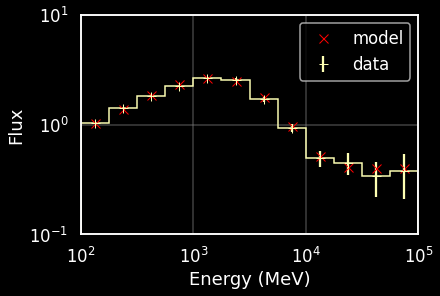

### Use Likelihood framework to fit the model to the data

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x77c3e1db40a0>

In [24]:
%reset -f
%run pylib/tools dark
from utilities.ipynb_docgen import show, capture_hide
from pylib.tools import np
from importlib import reload
from like3 import likelihood as lk; reload(lk)
from like3 import demo_model as dm; reload(dm)
from like3 import sourcelist as sl; reload(sl)

show(f"""### Create a DemoModel with a pulsar and a blazar """)

model = dm.DemoModel.test(plot=True, src_key=2, random_state=42)

show(f""" ### Use Likelihood framework to fit the model to the data""")
with capture_hide('Fit summary') as cap:
    self = lk.Likelihood(model=model, data=model.data)
    print(self.model[0].model)
    self.maximize()
    self.summary()
    print(self.model[0].model)
show(cap)


## Add PSF, locality dependence

In [25]:
print('Previous one bin per band:', model.counts().astype(int))

Previous one bin per band: [7779 5854 4375 3097 1960 1034  421  128   37   16    8    4]


Model: 2 sources, 4 free parameters


Band(energy=750.0 MeV, et=0 nside=128)

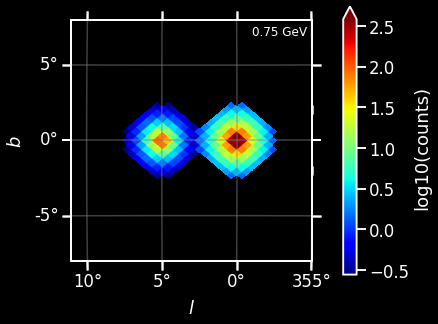

In [26]:
from like3 import bands; reload(bands)
from like3.bands import BandList, Band
from like3.sourcelist import SourceList
from pylib.psf_func import PSFlist

df = PSFlist.demo_df() 
self = Band(df.iloc[3], SourceList.demo()); 
show(self)
k, v = self.pixel_counts()
self.plot_pixel_map((3,0),log=True, size=16)

In [27]:
def loglike(self, test_source):
    """Compute the log-likelihood for the source parameters given the data."""

    data_pix, counts = self.data
    flux = test_source.model(self.energy)
    source_pix, v = test_source.response(self).evaluate()

    mask = np.isin(source_pix, data_pix)
    
    model = v[mask]
    model *= self.exposure_map(source_pix[mask]) * flux
    model = np.clip(model, 1e-6, None)

    return np.sum(counts[np.isin(data_pix, source_pix)] * np.log(model) - model)

### Develop Band localization likelihood function

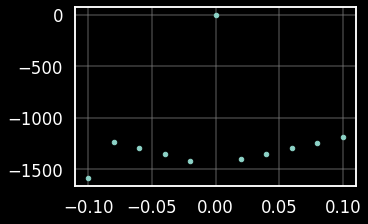

In [33]:
show(f"""### Develop Band localization likelihood function""")


from astropy.coordinates import SkyCoord
self.data = self.simulate()

test = self.source_model[0].copy()
z0 = loglike(self, test) 

ll = np.linspace(-.1,.1, 11)
sdd = SkyCoord(ll, test.skydir.b.deg, unit='deg', frame='galactic')
y = [loglike(self, PointSource(name='', skydir=skydir, model=test.model))-z0 for skydir in sdd]
plt.plot(ll, y, '.');

In [17]:
test.copy(skydir=sdd[-1]).skydir.l.deg,

(0.1,)

In [ ]:
sum(mask), len(model), len(counts),#len(counts[mask])

(62, 62, 145)

In [ ]:
ap(keys[mask]) * flux
model = np.clip(model, 1e-6, None)


In [ ]:
from like3.sources import PointSource
PointSource(name=source.name, skydir=source.skydir, model=source.model)
source.skydir

<SkyCoord (Galactic): (l, b) in deg
    (5., 0.)>

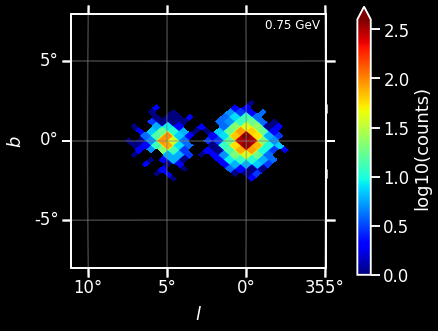

In [ ]:
self.plot_pixel_map((3,0), data=self.data, log=True, size=16)

In [ ]:
sd = SourceList.demo()
for s in sd:
    show(s)

Model: 2 sources, 4 free parameters


like3.sources.PointSource: 
	name  : Pulsar
	ICRS  : (266.405, -28.936)
	model : PLSuperExpCutoff4
		Norm      : 1e-11 
		Index     : 2 
		Curvature : 0.7 (FROZEN)
		b         : 0.69 (FROZEN)

like3.sources.PointSource: 
	name  : Blazar
	ICRS  : (269.269, -24.638)
	model : LogParabola
		Norm      : 4e-12 
		Index     : 2 
		beta      : 0 (FROZEN)
		E_break   : 1e+03 (FROZEN)

In [ ]:
g = self.pixel_gradient((k,v))
g.shape

(62, 4)

In [ ]:
self.psf.event_type

0